# Bài Tập Lập Trình — Xử lý ảnh số
## Chương 3 & 4: Phát hiện cạnh, Phân đoạn ảnh

### Hướng dẫn chọn bài

Sinh viên làm **đúng 2 bài** — một bài từ mỗi nhóm:

| Nhóm | Chọn **1 trong 2** | Điểm |
|------|-------------------|------|
| **Nhóm A** (Chương 3) | Bài 1 — Canny *hoặc* Bài 2 — Harris | 50 |
| **Nhóm B** (Chương 4) | Bài 3 — Split & Merge *hoặc* Bài 4 — Mean-Shift | 50 |

> **Cách dùng notebook này:** Scroll đến bài bạn chọn và chỉ chạy các cell thuộc bài đó. Các cell của bài không chọn có thể bỏ qua.

---

**Yêu cầu:** `numpy`, `matplotlib`, `scipy`, `opencv-python`

**Quy ước:**
- `# TODO` — bạn phải viết code tại đây
- `# GIVEN` — code được cung cấp sẵn, không cần sửa (nhưng hãy đọc hiểu)
- `# TEST` — cell kiểm tra, chạy sau khi hoàn thành TODO

In [21]:
# GIVEN — Import và cài đặt chung
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import convolve, gaussian_filter
import cv2

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
np.set_printoptions(precision=4, suppress=True)

print('✓ Thư viện đã sẵn sàng.')

✓ Thư viện đã sẵn sàng.


---
# Bài 1 — Tự cài đặt bộ lọc Canny

Cài đặt hàm `my_canny(image, sigma, t_low, t_high)` với bốn bước:
1. Làm mịn Gaussian
2. Tính gradient (Sobel)
3. Non-maximum suppression
4. Hysteresis thresholding

**Thư viện được phép:** `numpy`, `matplotlib`, `scipy.ndimage.convolve`  
**Cấm:** `cv2.Canny`, `skimage.feature.canny`, `scipy.ndimage.sobel`

## Bước 1 — Làm mịn Gaussian

Tạo Gaussian kernel kích thước $(2\lceil 3\sigma \rceil + 1)^2$ và thực hiện convolution 2D.

**Nhắc nhở:** Gaussian 2D tách được thành tích hai Gaussian 1D:
$$G(x,y) = \frac{1}{2\pi\sigma^2} e^{-(x^2+y^2)/2\sigma^2}$$

In [22]:
def make_gaussian_kernel(sigma):
    """
    Tạo Gaussian kernel 2D chuẩn hóa.
    Kích thước kernel: (2 * ceil(3*sigma) + 1) x (2 * ceil(3*sigma) + 1)
    
    Tham số:
        sigma (float): độ lệch chuẩn của Gaussian
    Trả về:
        kernel (ndarray): Gaussian kernel 2D, tổng = 1
    """
    # TODO: Tính kích thước kernel
    half = int(np.ceil(3 * sigma))
    size = 2 * half + 1
    
    # TODO: Tạo lưới tọa độ x, y
    ax = np.arange(-half, half + 1)  # shape (size,)
    xx, yy = np.meshgrid(ax, ax)     # shape (size, size)
    
    # TODO: Tính giá trị Gaussian tại mỗi điểm
    # G(x,y) = exp(-(x^2 + y^2) / (2*sigma^2))
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    
    # TODO: Chuẩn hóa để tổng kernel = 1
    kernel = kernel / kernel.sum()
    
    return kernel


✓ make_gaussian_kernel: kích thước (7, 7), tổng = 1.000000


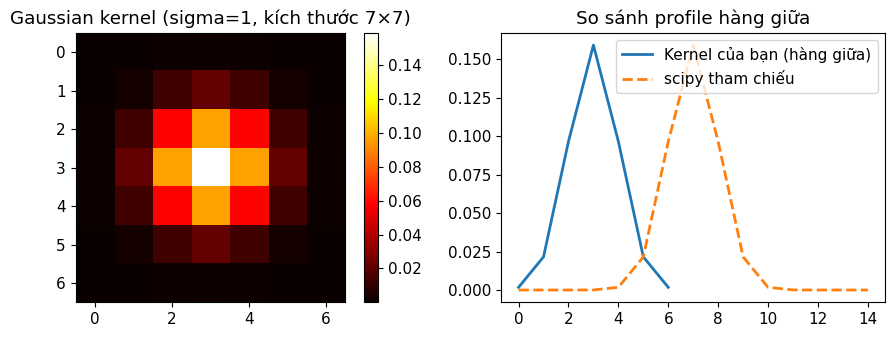

In [23]:
# TEST — Kiểm tra make_gaussian_kernel
k = make_gaussian_kernel(sigma=1.0)
assert k is not None, 'Hàm chưa trả về kết quả'
assert k.ndim == 2, f'Kernel phải là 2D, nhận được {k.ndim}D'
assert k.shape[0] == k.shape[1], 'Kernel phải vuông'
assert k.shape[0] == 7, f'Với sigma=1, kích thước phải là 7, nhận được {k.shape[0]}'
assert abs(k.sum() - 1.0) < 1e-6, f'Tổng kernel phải = 1, nhận được {k.sum():.6f}'
assert k[k.shape[0]//2, k.shape[1]//2] == k.max(), 'Giá trị lớn nhất phải ở tâm'
print(f'✓ make_gaussian_kernel: kích thước {k.shape}, tổng = {k.sum():.6f}')

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].imshow(k, cmap='hot')
axes[0].set_title(f'Gaussian kernel (sigma=1, kích thước {k.shape[0]}×{k.shape[1]})')
axes[0].colorbar = plt.colorbar(axes[0].images[0], ax=axes[0])

# So sánh với scipy
from scipy.ndimage import gaussian_filter
delta = np.zeros((15, 15)); delta[7, 7] = 1.0
ref = gaussian_filter(delta, sigma=1.0)
axes[1].plot(k[k.shape[0]//2], label='Kernel của bạn (hàng giữa)', lw=2)
axes[1].plot(ref[7], '--', label='scipy tham chiếu', lw=2)
axes[1].set_title('So sánh profile hàng giữa')
axes[1].legend()
plt.tight_layout()
plt.show()

## Bước 2 — Tính gradient bằng Sobel

Tạo kernel Sobel 3×3 thủ công và dùng `scipy.ndimage.convolve`.

$$S_x = \begin{pmatrix}-1&0&1\\-2&0&2\\-1&0&1\end{pmatrix}, \quad S_y = \begin{pmatrix}-1&-2&-1\\0&0&0\\1&2&1\end{pmatrix}$$

In [24]:
def compute_gradient(image):
    """
    Tính gradient ảnh bằng kernel Sobel 3x3.
    
    Tham số:
        image (ndarray): ảnh grayscale 2D, giá trị float
    Trả về:
        magnitude (ndarray): độ lớn gradient, cùng kích thước với image
        angle (ndarray): góc gradient (radian), trong [-pi, pi]
    """
    # TODO: Định nghĩa kernel Sobel Sx và Sy dưới dạng numpy array
    Sx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=float)  # phát hiện gradient ngang
    Sy = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]], dtype=float)  # phát hiện gradient dọc
    
    # TODO: Tính Gx = convolve(image, Sx) và Gy = convolve(image, Sy)
    Gx = convolve(image.astype(float), Sx)
    Gy = convolve(image.astype(float), Sy)
    
    # TODO: Tính magnitude = sqrt(Gx^2 + Gy^2)
    magnitude = np.sqrt(Gx**2 + Gy**2)
    
    # TODO: Tính angle = atan2(Gy, Gx)
    angle = np.arctan2(Gy, Gx)
    
    return magnitude, angle


✓ compute_gradient: magnitude max = 4.000, shape = (20, 20)


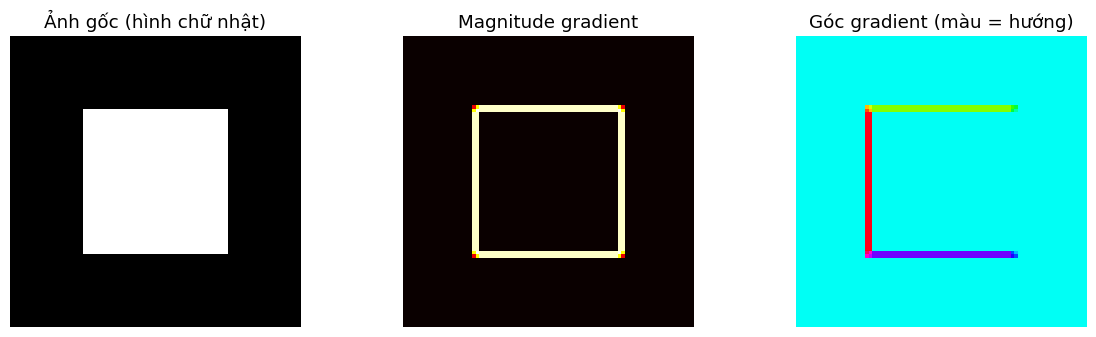

Quan sát: gradient mạnh nhất ở 4 cạnh của hình chữ nhật


In [25]:
# TEST — Kiểm tra compute_gradient
# Ảnh test: gradient nằm ngang (bên trái đen, bên phải trắng)
test_img = np.zeros((20, 20), dtype=float)
test_img[:, 10:] = 1.0

result = compute_gradient(test_img)
assert result is not None, 'Hàm chưa trả về kết quả'
mag, ang = result
assert mag.shape == test_img.shape, f'magnitude phải cùng kích thước ảnh, nhận {mag.shape}'
assert ang.shape == test_img.shape, f'angle phải cùng kích thước ảnh, nhận {ang.shape}'
assert mag[:, 10].mean() > mag[:, 0].mean(), 'Gradient phải lớn nhất tại biên'
print(f'✓ compute_gradient: magnitude max = {mag.max():.3f}, shape = {mag.shape}')

# Trực quan hóa trên ảnh thực tế hơn
# Tạo ảnh test: hình chữ nhật trắng trên nền đen
test_rect = np.zeros((80, 80), dtype=float)
test_rect[20:60, 20:60] = 1.0

mag_rect, ang_rect = compute_gradient(test_rect)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].imshow(test_rect, cmap='gray')
axes[0].set_title('Ảnh gốc (hình chữ nhật)')
axes[1].imshow(mag_rect, cmap='hot')
axes[1].set_title('Magnitude gradient')
axes[2].imshow(ang_rect, cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[2].set_title('Góc gradient (màu = hướng)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print('Quan sát: gradient mạnh nhất ở 4 cạnh của hình chữ nhật')

## Bước 3 — Non-Maximum Suppression (NMS)

Lượng tử hóa góc về 4 hướng, giữ lại pixel là cực đại cục bộ theo hướng gradient.

| Góc $\theta$ | Hướng | Hàng xóm cần so sánh |
|---|---|---|
| $[-22.5°, 22.5°)$ hoặc $[157.5°, 180°]$ | 0° (ngang) | $(i, j-1)$ và $(i, j+1)$ |
| $[22.5°, 67.5°)$ | 45° | $(i-1, j-1)$ và $(i+1, j+1)$ |
| $[67.5°, 112.5°)$ | 90° (đứng) | $(i-1, j)$ và $(i+1, j)$ |
| $[112.5°, 157.5°)$ | 135° | $(i-1, j+1)$ và $(i+1, j-1)$ |

In [ ]:
def non_maximum_suppression(magnitude, angle):
    """
    Làm mỏng cạnh bằng non-maximum suppression.
    Với mỗi pixel, chỉ giữ lại nếu nó là cực đại cục bộ
    theo hướng gradient.
    
    Tham số:
        magnitude (ndarray): độ lớn gradient (H, W)
        angle (ndarray): góc gradient radian (H, W), trong [-pi, pi]
    Trả về:
        suppressed (ndarray): magnitude sau NMS, cùng shape, 
                              pixels không phải cực đại bị đặt về 0
    """
    H, W = magnitude.shape
    suppressed = np.zeros_like(magnitude)
    
    # TODO: Chuyển angle sang độ và lấy giá trị tuyệt đối
    # (gradient 0° và 180° là cùng hướng cho NMS)
    angle_deg = np.abs(np.degrees(angle))  # [0, 180]
    
    # TODO: Duyệt qua mỗi pixel (i, j), bỏ qua viền 1 pixel
    # Với mỗi pixel:
    #   1. Xác định hướng: 0, 45, 90, hoặc 135 độ
    #   2. Lấy hai hàng xóm theo hướng đó
    #   3. Nếu magnitude[i,j] >= cả hai hàng xóm -> giữ lại
    
    for i in range(1, H - 1):
        for j in range(1, W - 1):
            theta = angle_deg[i, j]
            
            # Xác định hai hàng xóm theo hướng gradient
            if theta < 22.5 or theta >= 157.5:    # hướng 0° (ngang)
                n1 = magnitude[i, j - 1]
                n2 = magnitude[i, j + 1]
            elif theta < 67.5:                    # hướng 45°
                n1 = magnitude[i - 1, j - 1]
                n2 = magnitude[i + 1, j + 1]
            elif theta < 112.5:                   # hướng 90° (dọc)
                n1 = magnitude[i - 1, j]
                n2 = magnitude[i + 1, j]
            else:                                 # hướng 135°
                n1 = magnitude[i - 1, j + 1]
                n2 = magnitude[i + 1, j - 1]
            
            # Giữ lại pixel nếu là cực đại cục bộ
            if magnitude[i, j] >= n1 and magnitude[i, j] >= n2:
                suppressed[i, j] = magnitude[i, j]
    
    return suppressed


✓ NMS: pixel cạnh trước=1248, sau=194 (giảm 84.5%)


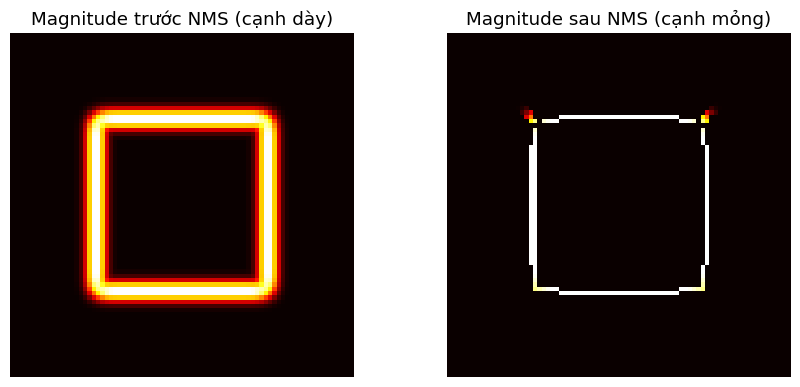

In [27]:
# TEST — Kiểm tra NMS
# Dùng kết quả gradient từ bước 2
gauss_k = make_gaussian_kernel(sigma=1.5)
smooth_rect = convolve(test_rect, gauss_k)
mag_s, ang_s = compute_gradient(smooth_rect)

nms_result = non_maximum_suppression(mag_s, ang_s)
assert nms_result is not None, 'Hàm chưa trả về kết quả'
assert nms_result.shape == mag_s.shape

# Sau NMS, số pixel khác 0 phải ít hơn trước NMS (đường cạnh mỏng hơn)
before = np.sum(mag_s > 0.1)
after  = np.sum(nms_result > 0.1)
assert after < before, f'NMS phải giảm số pixel cạnh: trước={before}, sau={after}'
print(f'✓ NMS: pixel cạnh trước={before}, sau={after} (giảm {100*(before-after)/before:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(mag_s, cmap='hot')
axes[0].set_title('Magnitude trước NMS (cạnh dày)')
axes[1].imshow(nms_result, cmap='hot')
axes[1].set_title('Magnitude sau NMS (cạnh mỏng)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## Bước 4 — Hysteresis Thresholding

- Pixel với `magnitude > t_high` → **cạnh chắc chắn** (strong)
- Pixel với `t_low < magnitude <= t_high` → **cạnh yếu** (weak)
- Cạnh yếu chỉ được giữ nếu **8-liên thông** với ít nhất một cạnh chắc

In [28]:
def hysteresis_threshold(magnitude, t_low, t_high):
    """
    Áp dụng double thresholding và hysteresis.
    
    Tham số:
        magnitude (ndarray): magnitude sau NMS
        t_low (float): ngưỡng thấp
        t_high (float): ngưỡng cao
    Trả về:
        edges (ndarray): bản đồ cạnh nhị phân (bool hoặc 0/1)
    """
    H, W = magnitude.shape
    
    # TODO: Tạo mask strong và weak
    strong = magnitude > t_high
    weak   = (magnitude > t_low) & (magnitude <= t_high)
    
    # TODO: Khởi tạo bản đồ cạnh với chỉ các cạnh strong
    edges = strong.copy()
    
    # TODO: BFS từ các cạnh strong — lan truyền sang weak 8-liên thông
    from collections import deque
    queue = deque(zip(*np.where(strong)))
    
    # 8 hướng hàng xóm
    neighbors = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
    
    while queue:
        i, j = queue.popleft()
        for di, dj in neighbors:
            ni, nj = i + di, j + dj
            if 0 <= ni < H and 0 <= nj < W:
                if weak[ni, nj] and not edges[ni, nj]:
                    edges[ni, nj] = True
                    queue.append((ni, nj))
    
    return edges


In [29]:
# TEST — Kiểm tra hysteresis thresholding
# Ví dụ nhỏ: một chuỗi pixel kết nối strong->weak->weak
test_mag = np.array([
    [0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.9, 0.6, 0.5, 0.0],  # 0.9=strong, 0.6 và 0.5=weak (nếu t_low=0.3, t_high=0.7)
    [0.0, 0.0, 0.0, 0.0, 0.0],
])
result_ht = hysteresis_threshold(test_mag, t_low=0.3, t_high=0.7)
assert result_ht is not None, 'Hàm chưa trả về kết quả'
assert result_ht[1, 1], 'Pixel strong phải là cạnh'
assert result_ht[1, 2], 'Pixel weak kề strong phải là cạnh'
assert result_ht[1, 3], 'Pixel weak kề weak-đã-kết-nối phải là cạnh'
print('✓ hysteresis_threshold: lan truyền cạnh hoạt động đúng')

# Kiểm tra: pixel yếu bị cô lập không được giữ
test_isolated = np.array([[0,0,0],[0,0.5,0],[0,0,0]], dtype=float)
res_iso = hysteresis_threshold(test_isolated, t_low=0.3, t_high=0.7)
assert not res_iso[1,1], 'Pixel weak cô lập KHÔNG được là cạnh'
print('✓ Pixel weak cô lập bị loại đúng')

✓ hysteresis_threshold: lan truyền cạnh hoạt động đúng
✓ Pixel weak cô lập bị loại đúng


## Tổng hợp — Hàm `my_canny`

In [30]:
def my_canny(image, sigma=1.0, t_low=0.05, t_high=0.15):
    """
    Canny edge detector hoàn chỉnh.
    
    Tham số:
        image    (ndarray): ảnh grayscale 2D (uint8 hoặc float)
        sigma    (float):   độ lệch chuẩn Gaussian làm mịn
        t_low    (float):   ngưỡng thấp (tỉ lệ của max magnitude)
        t_high   (float):   ngưỡng cao
    Trả về:
        edges (ndarray): bản đồ cạnh nhị phân
    """
    # Chuẩn hóa ảnh về [0, 1]
    img = image.astype(float)
    if img.max() > 1.0:
        img = img / 255.0
    
    # TODO: Bước 1 — Làm mịn: dùng make_gaussian_kernel + convolve
    kernel = make_gaussian_kernel(sigma)
    smoothed = convolve(img, kernel)
    
    # TODO: Bước 2 — Tính gradient: dùng compute_gradient
    magnitude, angle = compute_gradient(smoothed)
    
    # TODO: Chuẩn hóa ngưỡng nếu t_low/t_high là tỉ lệ (nhân với max magnitude)
    # Giúp my_canny dễ dùng vì không phụ thuộc vào scale ảnh
    mag_max = magnitude.max()
    if mag_max > 0:
        tl = t_low  * mag_max
        th = t_high * mag_max
    else:
        tl, th = t_low, t_high
    
    # TODO: Bước 3 — NMS: dùng non_maximum_suppression
    nms = non_maximum_suppression(magnitude, angle)
    
    # TODO: Bước 4 — Hysteresis: dùng hysteresis_threshold
    edges = hysteresis_threshold(nms, tl, th)
    
    return edges


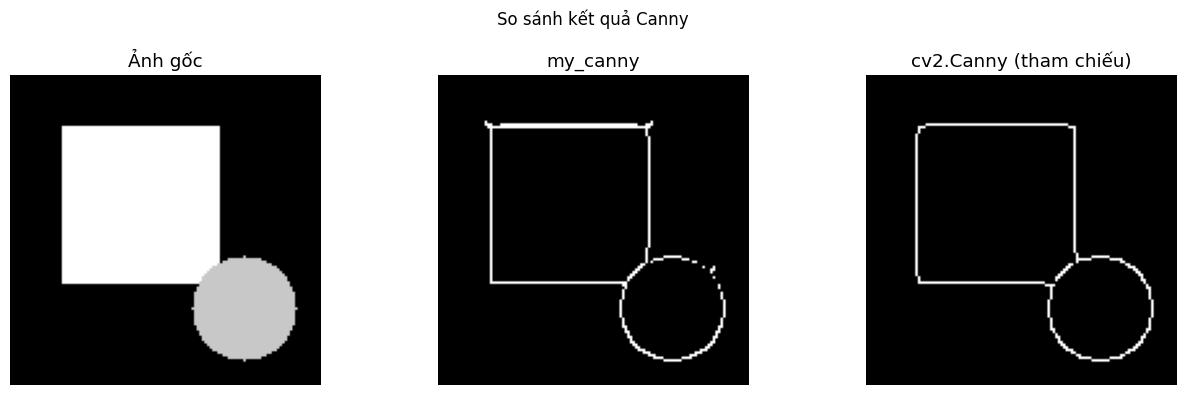

Kết quả không cần giống cv2.Canny hoàn toàn — nhưng cấu trúc cạnh phải tương đương.


In [31]:
# TEST — So sánh my_canny với cv2.Canny

# --- Ảnh test 1: hình tổng hợp ---
synth = np.zeros((120, 120), dtype=np.uint8)
cv2.rectangle(synth, (20, 20), (80, 80), 255, -1)
cv2.circle(synth, (90, 90), 20, 200, -1)

# --- Chạy my_canny ---
edges_mine = my_canny(synth, sigma=1.0, t_low=0.05, t_high=0.15)
assert edges_mine is not None, 'my_canny chưa trả về kết quả'

# --- Chạy cv2.Canny để so sánh trực quan ---
synth_blur = cv2.GaussianBlur(synth, (7, 7), 1.0)
edges_cv2 = cv2.Canny(synth_blur, threshold1=12, threshold2=36)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(synth, cmap='gray')
axes[0].set_title('Ảnh gốc')
axes[1].imshow(edges_mine, cmap='gray')
axes[1].set_title('my_canny')
axes[2].imshow(edges_cv2, cmap='gray')
axes[2].set_title('cv2.Canny (tham chiếu)')
for ax in axes: ax.axis('off')
plt.suptitle('So sánh kết quả Canny', fontsize=12)
plt.tight_layout()
plt.show()

print('Kết quả không cần giống cv2.Canny hoàn toàn — nhưng cấu trúc cạnh phải tương đương.')

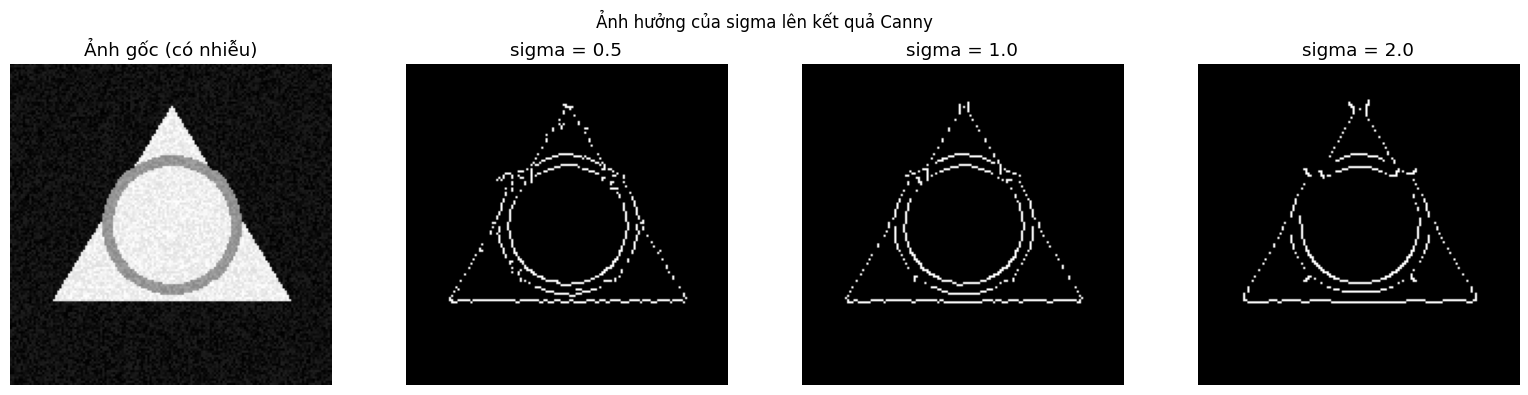

In [32]:
# TODO — Phân tích: Thử nghiệm ảnh thực và trả lời câu hỏi phân tích

# Ảnh tổng hợp phức tạp có nhiễu
complex_synth = np.zeros((150, 150), dtype=np.uint8)
pts = np.array([[75,20],[130,110],[20,110]], dtype=np.int32)
cv2.fillPoly(complex_synth, [pts], 200)
cv2.circle(complex_synth, (75, 75), 30, 120, 3)
noise = np.random.randint(0, 30, complex_synth.shape, dtype=np.uint8)
complex_synth = np.clip(complex_synth.astype(int) + noise, 0, 255).astype(np.uint8)

# Thử 3 giá trị sigma và quan sát sự thay đổi
sigmas = [0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, len(sigmas) + 1, figsize=(16, 4))
axes[0].imshow(complex_synth, cmap='gray')
axes[0].set_title('Ảnh gốc (có nhiễu)')
axes[0].axis('off')

for ax, s in zip(axes[1:], sigmas):
    edge_result = my_canny(complex_synth, sigma=s, t_low=0.05, t_high=0.15)
    ax.imshow(edge_result, cmap='gray')
    ax.set_title(f'sigma = {s}')
    ax.axis('off')

plt.suptitle('Ảnh hưởng của sigma lên kết quả Canny', fontsize=12)
plt.tight_layout()
plt.show()


---
# Bài 2 — Harris mở rộng với phân loại đặc trưng

Xây dựng Harris detector đầy đủ, sau đó mở rộng để phân loại pixel thành góc/cạnh/phẳng dựa trên eigenvalue của ma trận cấu trúc $M$.

**Thư viện được phép:** `numpy`, `matplotlib`, `scipy.ndimage`, `cv2` (chỉ để đọc ảnh và tính Canny), `numpy.linalg.eigh`  
**Cấm:** `cv2.cornerHarris`, `skimage.feature.corner_harris`, `skimage.feature.corner_eigenvals`

## Bước 1 — Ma trận cấu trúc $M$

$$M(x,y) = \sum_{(u,v) \in W} w(u,v) \begin{pmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{pmatrix}$$

Trong đó $w(u,v)$ là Gaussian window và $I_x$, $I_y$ là đạo hàm ảnh.

In [33]:
def compute_structure_matrix(image, sigma_deriv=1.0, sigma_window=1.5):
    """
    Tính 4 thành phần của ma trận cấu trúc M tại mỗi pixel.
    
    Tham số:
        image        (ndarray): ảnh grayscale float (H, W)
        sigma_deriv  (float):   sigma để làm mịn trước khi lấy đạo hàm
        sigma_window (float):   sigma của cửa sổ Gaussian tích lũy
    Trả về:
        M_xx (ndarray): thành phần (0,0) của M, shape (H,W) — tổng Ix^2
        M_xy (ndarray): thành phần (0,1) của M, shape (H,W) — tổng Ix*Iy
        M_yy (ndarray): thành phần (1,1) của M, shape (H,W) — tổng Iy^2
    """
    img = image.astype(float)
    if img.max() > 1.0:
        img = img / 255.0
    
    # TODO: Làm mịn ảnh với Gaussian sigma_deriv trước khi lấy đạo hàm
    from scipy.ndimage import gaussian_filter
    smoothed = gaussian_filter(img, sigma=sigma_deriv)
    
    # TODO: Tính Ix và Iy bằng kernel Sobel
    Sx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
    Sy = np.array([[-1,-2,-1], [ 0, 0, 0], [ 1, 2, 1]], dtype=float)
    Ix = convolve(smoothed, Sx)
    Iy = convolve(smoothed, Sy)
    
    # TODO: Tính các sản phẩm: Ix2 = Ix*Ix, Ixy = Ix*Iy, Iy2 = Iy*Iy
    Ix2 = Ix * Ix
    Ixy = Ix * Iy
    Iy2 = Iy * Iy
    
    # TODO: Làm mịn mỗi sản phẩm với Gaussian sigma_window (bước tích lũy cửa sổ)
    M_xx = gaussian_filter(Ix2, sigma=sigma_window)
    M_xy = gaussian_filter(Ixy, sigma=sigma_window)
    M_yy = gaussian_filter(Iy2, sigma=sigma_window)
    
    return M_xx, M_xy, M_yy


✓ compute_structure_matrix: M_xx max=3.6074, M_yy max=3.6074


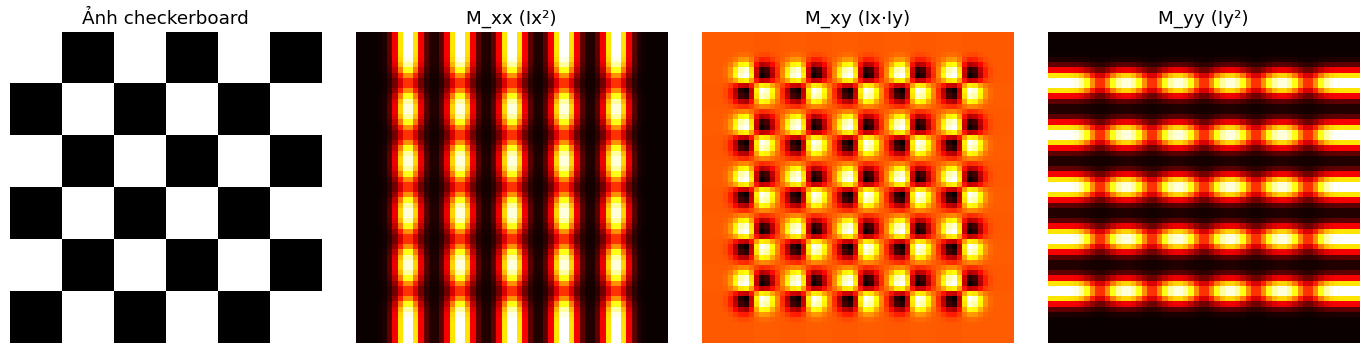

Quan sát: M_xx lớn ở cạnh dọc, M_yy lớn ở cạnh ngang


In [34]:
# TEST — Kiểm tra compute_structure_matrix
test_checker = np.zeros((60, 60), dtype=np.uint8)
for i in range(6):
    for j in range(6):
        if (i + j) % 2 == 0:
            test_checker[i*10:(i+1)*10, j*10:(j+1)*10] = 255

result_M = compute_structure_matrix(test_checker)
assert result_M is not None, 'Hàm chưa trả về kết quả'
M_xx, M_xy, M_yy = result_M
assert M_xx.shape == test_checker.shape
assert M_yy.shape == test_checker.shape
# Trên checkerboard, M_xx và M_yy đều phải có giá trị khác 0
assert M_xx.max() > 0 and M_yy.max() > 0
print(f'✓ compute_structure_matrix: M_xx max={M_xx.max():.4f}, M_yy max={M_yy.max():.4f}')

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(test_checker, cmap='gray')
axes[0].set_title('Ảnh checkerboard')
axes[1].imshow(M_xx, cmap='hot')
axes[1].set_title('M_xx (Ix²)')
axes[2].imshow(M_xy, cmap='hot')
axes[2].set_title('M_xy (Ix·Iy)')
axes[3].imshow(M_yy, cmap='hot')
axes[3].set_title('M_yy (Iy²)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print('Quan sát: M_xx lớn ở cạnh dọc, M_yy lớn ở cạnh ngang')

## Bước 2 — Tính Eigenvalue và Phân loại

Phân loại mỗi pixel dựa trên $\lambda_1 \geq \lambda_2 \geq 0$:

| Điều kiện | Loại | Ý nghĩa |
|---|---|---|
| $\lambda_1 \leq \tau$ | **Phẳng** | Không có cấu trúc |
| $\lambda_1 > \tau$ và $\lambda_1/\lambda_2 \geq r$ | **Cạnh** | Một hướng gradient mạnh |
| $\lambda_2 > \tau$ và $\lambda_1/\lambda_2 < r$ | **Góc** | Hai hướng gradient mạnh |

In [35]:
def compute_eigenvalue_map(M_xx, M_xy, M_yy):
    """
    Tính λ1 ≥ λ2 tại mỗi pixel từ các thành phần ma trận cấu trúc.
    
    Công thức trực tiếp cho ma trận 2x2:
        trace = M_xx + M_yy
        det   = M_xx * M_yy - M_xy^2
        disc  = sqrt((trace/2)^2 - det)
        λ1    = trace/2 + disc
        λ2    = trace/2 - disc
    
    Trả về:
        lam1 (ndarray): eigenvalue lớn hơn tại mỗi pixel
        lam2 (ndarray): eigenvalue nhỏ hơn tại mỗi pixel
    """
    # TODO: Tính trace và determinant
    trace = M_xx + M_yy
    det   = M_xx * M_yy - M_xy**2
    
    # TODO: Tính discriminant (đảm bảo không âm với np.maximum(..., 0))
    disc = np.sqrt(np.maximum((trace / 2)**2 - det, 0))
    
    # TODO: Tính lam1 và lam2
    lam1 = trace / 2 + disc
    lam2 = trace / 2 - disc
    
    return lam1, lam2


def classify_features(lam1, lam2, tau=0.01, r=10.0):
    """
    Phân loại mỗi pixel thành FLAT / EDGE / CORNER.
    
    Tham số:
        lam1, lam2 (ndarray): eigenvalue tại mỗi pixel (lam1 >= lam2)
        tau  (float): ngưỡng eigenvalue tối thiểu
        r    (float): ngưỡng tỷ lệ lam1/lam2 để phân biệt cạnh và góc
    Trả về:
        label_map (ndarray int): 0=FLAT, 1=EDGE, 2=CORNER, shape = lam1.shape
    """
    # TODO: Tạo label_map toàn 0 (FLAT)
    label_map = np.zeros(lam1.shape, dtype=int)
    
    # Tỷ lệ lam1/lam2 — tránh chia cho 0
    ratio = np.where(lam2 > 1e-10, lam1 / lam2, np.inf)
    
    # TODO: Đặt EDGE (1) nơi lambda1 > tau VÀ lambda1/lambda2 >= r
    edge_mask = (lam1 > tau) & (ratio >= r)
    label_map[edge_mask] = 1
    
    # TODO: Đặt CORNER (2) nơi lambda2 > tau VÀ lambda1/lambda2 < r
    # CORNER ghi đè EDGE nếu cả hai điều kiện đều thỏa
    corner_mask = (lam2 > tau) & (ratio < r)
    label_map[corner_mask] = 2
    
    return label_map


✓ eigenvalue: lam1 max=3.6074, lam2 max=1.5575
✓ Phân loại: FLAT=140, EDGE=1960, CORNER=1500


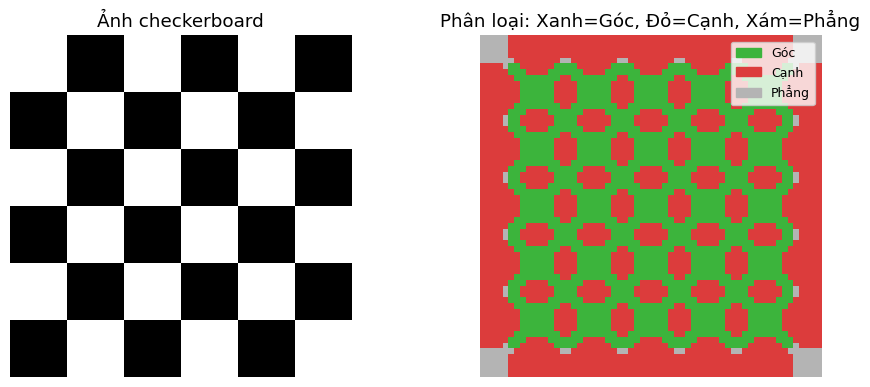

In [36]:
# TEST — Kiểm tra eigenvalue và phân loại
M_xx, M_xy, M_yy = compute_structure_matrix(test_checker)

result_eig = compute_eigenvalue_map(M_xx, M_xy, M_yy)
assert result_eig is not None, 'compute_eigenvalue_map chưa trả về kết quả'
lam1, lam2 = result_eig
assert np.all(lam1 >= lam2 - 1e-10), 'lam1 phải >= lam2 tại mọi pixel'
assert np.all(lam2 >= -1e-10), 'lam2 phải >= 0'
print(f'✓ eigenvalue: lam1 max={lam1.max():.4f}, lam2 max={lam2.max():.4f}')

labels = classify_features(lam1, lam2, tau=lam1.max()*0.01, r=8.0)
assert labels is not None, 'classify_features chưa trả về kết quả'
n_corner = np.sum(labels == 2)
n_edge   = np.sum(labels == 1)
n_flat   = np.sum(labels == 0)
print(f'✓ Phân loại: FLAT={n_flat}, EDGE={n_edge}, CORNER={n_corner}')
assert n_corner > 0, 'Trên checkerboard phải có ít nhất một góc'

# Trực quan hóa bản đồ màu
color_map = np.zeros((*labels.shape, 3), dtype=np.uint8)
color_map[labels == 0] = [180, 180, 180]  # xám = phẳng
color_map[labels == 1] = [220,  60,  60]  # đỏ = cạnh
color_map[labels == 2] = [ 60, 180,  60]  # xanh = góc

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(test_checker, cmap='gray')
axes[0].set_title('Ảnh checkerboard')
axes[1].imshow(color_map)
axes[1].set_title('Phân loại: Xanh=Góc, Đỏ=Cạnh, Xám=Phẳng')
patches = [mpatches.Patch(color=[c/255 for c in col], label=lbl)
           for col, lbl in [([60,180,60],'Góc'), ([220,60,60],'Cạnh'), ([180,180,180],'Phẳng')]]
axes[1].legend(handles=patches, loc='upper right', fontsize=9)
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## Bước 3 — Đánh giá so với Canny

In [37]:
# GIVEN — Hàm đánh giá precision của bộ phát hiện cạnh từ eigenvalue
def evaluate_edge_precision(label_map, canny_edges):
    """
    Tính precision: trong số pixel được phát hiện là EDGE hoặc CORNER,
    bao nhiêu % thực sự nằm trên cạnh Canny?
    """
    detected = (label_map >= 1)   # pixel được đánh là EDGE hoặc CORNER
    true_edge = (canny_edges > 0)
    tp = np.sum(detected & true_edge)
    fp = np.sum(detected & ~true_edge)
    precision = tp / (tp + fp + 1e-8)
    return precision, tp, fp


def corner_on_intersection(label_map, canny_edges):
    """
    Tính tỉ lệ pixel CORNER nằm tại giao điểm hai cạnh Canny.
    Giao điểm = pixel cạnh có ít nhất 2 hướng hàng xóm khác nhau (8-liên thông).
    """
    corners = (label_map == 2)
    edge_bin = (canny_edges > 0).astype(np.uint8)
    
    # Đếm số hàng xóm cạnh cho mỗi pixel cạnh
    kernel_8 = np.ones((3,3), dtype=np.uint8)
    neighbor_count = convolve(edge_bin.astype(float), kernel_8.astype(float))
    intersection = (neighbor_count >= 3) & (edge_bin > 0)  # ≥3 nghĩa là có ≥2 hàng xóm + chính nó
    
    n_corners = np.sum(corners)
    n_on_intersection = np.sum(corners & intersection)
    ratio = n_on_intersection / (n_corners + 1e-8)
    return ratio, n_corners, n_on_intersection

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21020\1194770113.py:45: RuntimeWarning: divide by zero encountered in divide
  ratio = np.where(lam2 > 1e-10, lam1 / lam2, np.inf)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21020\1194770113.py:45: RuntimeWarning: invalid value encountered in divide
  ratio = np.where(lam2 > 1e-10, lam1 / lam2, np.inf)


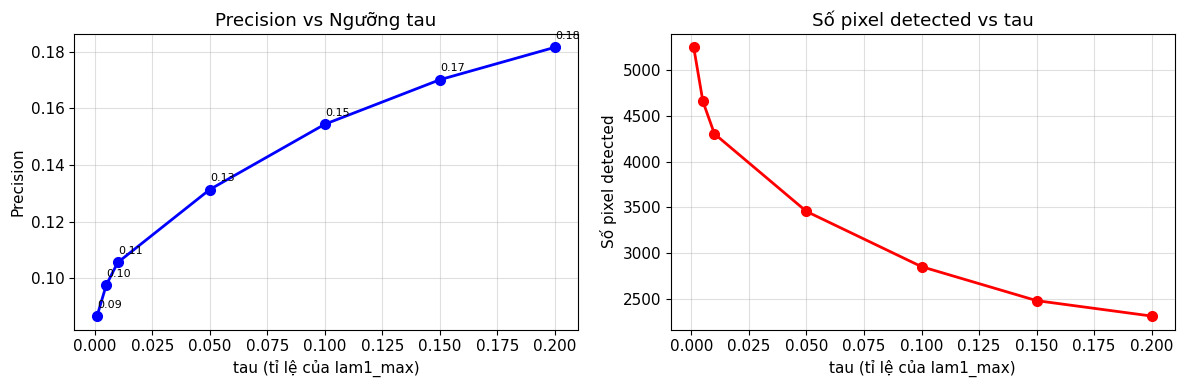

Nhận xét: tau càng lớn -> ít pixel được phát hiện -> precision tăng (ít nhiễu hơn)
tau tốt nhất: factor=0.2, precision=0.182


In [38]:
# TODO — Thử nghiệm với ít nhất 3 giá trị tau, vẽ đồ thị precision vs tau

# Chuẩn bị ảnh test có nhiều đặc trưng
test_eval = np.zeros((100, 100), dtype=np.uint8)
cv2.rectangle(test_eval, (10, 10), (50, 50), 255, -1)
cv2.rectangle(test_eval, (60, 10), (90, 90), 200, -1)
pts_tri = np.array([[50, 70],[20, 90],[80, 90]], dtype=np.int32)
cv2.fillPoly(test_eval, [pts_tri], 180)

# Cạnh Canny làm ground truth
canny_gt = cv2.Canny(test_eval, threshold1=50, threshold2=150)

# Tính M một lần
M_xx, M_xy, M_yy = compute_structure_matrix(test_eval)
lam1, lam2 = compute_eigenvalue_map(M_xx, M_xy, M_yy)

# Thử các giá trị tau
tau_factors = [0.001, 0.005, 0.01, 0.05, 0.1, 0.15, 0.2]
precisions = []
n_detected_list = []

for factor in tau_factors:
    tau = lam1.max() * factor
    labels = classify_features(lam1, lam2, tau=tau, r=8.0)
    prec, tp, fp = evaluate_edge_precision(labels, canny_gt)
    precisions.append(prec)
    n_detected_list.append(tp + fp)

# Vẽ đồ thị precision vs tau_factor
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tau_factors, precisions, 'b-o', linewidth=2, markersize=7)
axes[0].set_xlabel('tau (tỉ lệ của lam1_max)')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision vs Ngưỡng tau')
axes[0].grid(True, alpha=0.4)
for x, y in zip(tau_factors, precisions):
    axes[0].annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0,6), fontsize=8)

axes[1].plot(tau_factors, n_detected_list, 'r-o', linewidth=2, markersize=7)
axes[1].set_xlabel('tau (tỉ lệ của lam1_max)')
axes[1].set_ylabel('Số pixel detected')
axes[1].set_title('Số pixel detected vs tau')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print('Nhận xét: tau càng lớn -> ít pixel được phát hiện -> precision tăng (ít nhiễu hơn)')
best_idx = int(np.argmax(precisions))
print(f'tau tốt nhất: factor={tau_factors[best_idx]}, precision={precisions[best_idx]:.3f}')


---
# Bài 3 — Phân tách và Trộn (Split & Merge)

Cài đặt thuật toán Split & Merge hoàn chỉnh: phân tách ảnh đệ quy dựa trên tiêu chí đồng nhất, sau đó hợp nhất các vùng liền kề tương đồng.

**Thư viện được phép:** `numpy`, `matplotlib`, `scipy.ndimage`, `cv2` (chỉ đọc ảnh và Canny cho phần so sánh)  
**Cấm:** `skimage.segmentation.*`, `cv2.watershed`, bất kỳ hàm phân đoạn có sẵn nào

## Bước 1 — Tiêu chí đồng nhất $P(R)$

Một vùng $R$ được coi là đồng nhất nếu phương sai cường độ pixel nhỏ hơn ngưỡng $\theta$:
$$P(R) = \bigl(\sigma^2_R \leq \theta\bigr)$$

**Nhắc nhở:** Phương sai đo mức độ các pixel phân tán quanh giá trị trung bình. Vùng hoàn toàn đồng nhất có $\sigma^2 = 0$; vùng có cạnh đối tượng bên trong sẽ có $\sigma^2$ lớn.

In [39]:
def is_homogeneous(region, threshold):
    """
    Kiểm tra vùng ảnh có đồng nhất theo tiêu chí phương sai không.
    
    Tham số:
        region    (ndarray): vùng ảnh 2D, giá trị float trong [0, 1]
        threshold (float):   ngưỡng phương sai theta
    Trả về:
        True nếu variance(region) <= threshold, ngược lại False
    """
    # TODO: Tính phương sai của region và so sánh với threshold
    return np.var(region) <= threshold


In [40]:
# TEST — Kiểm tra is_homogeneous
flat_region   = np.full((8, 8), 0.5)                          # phương sai = 0
varied_region = np.array([[0.0]*4 + [1.0]*4]*8, dtype=float)  # phương sai lớn

assert is_homogeneous(flat_region, threshold=0.01) == True, \
    'Vùng đồng nhất phải trả về True'
assert is_homogeneous(varied_region, threshold=0.01) == False, \
    'Vùng không đồng nhất phải trả về False'
print(f'✓ is_homogeneous: var(flat)={np.var(flat_region):.4f}, var(varied)={np.var(varied_region):.4f}')


✓ is_homogeneous: var(flat)=0.0000, var(varied)=0.2500


## Bước 2 — Phân tách đệ quy (Split)

Chia đệ quy bất kỳ vùng nào không đồng nhất thành 4 vùng con bằng nhau.

```
split(region R):
    if P(R) == True or size(R) == 1x1:
        R là node lá — dừng
    else:
        chia R thành R_TL, R_TR, R_BL, R_BR  (top-left, top-right, ...)
        đệ quy split(R_TL), split(R_TR), split(R_BL), split(R_BR)
```

**Lưu ý:** Quad-tree hoạt động tốt nhất khi ảnh có kích thước $2^k \times 2^k$. Với ảnh kích thước tùy ý, dùng `np.array_split` hoặc cắt ngưỡng xuống kích thước chẵn.

In [41]:
def split(image, threshold, r=0, c=0, size=None):
    """
    Phân tách đệ quy ảnh thành các vùng đồng nhất (quad-tree).
    
    Tham số:
        image     (ndarray): ảnh gốc đầy đủ (H, W), float trong [0,1]
        threshold (float):   ngưỡng đồng nhất
        r, c      (int):     góc trên-trái của vùng hiện tại
        size      (int):     kích thước vùng hiện tại (vuông)
    Trả về:
        regions (list of tuples): danh sách các vùng lá (r, c, size)
                 mỗi tuple = (row_start, col_start, size)
    """
    if size is None:
        # Lấy cạnh nhỏ nhất và làm tròn xuống lũy thừa 2 gần nhất
        s = min(image.shape)
        size = 2 ** int(np.log2(s)) if s > 1 else 1
    
    # TODO: Lấy vùng con từ ảnh gốc
    region = image[r:r+size, c:c+size]
    
    # TODO: Điều kiện dừng: vùng 1x1 hoặc đồng nhất
    if size == 1 or is_homogeneous(region, threshold):
        return [(r, c, size)]
    
    # TODO: Chia thành 4 vùng con và đệ quy
    half = size // 2
    regions = []
    for (dr, dc) in [(0, 0), (0, half), (half, 0), (half, half)]:
        regions += split(image, threshold, r + dr, c + dc, half)
    return regions


✓ split: 4 vùng lá từ ảnh 8×8
  Các vùng: [(0, 0, 4), (0, 4, 4), (4, 0, 4), (4, 4, 4)]


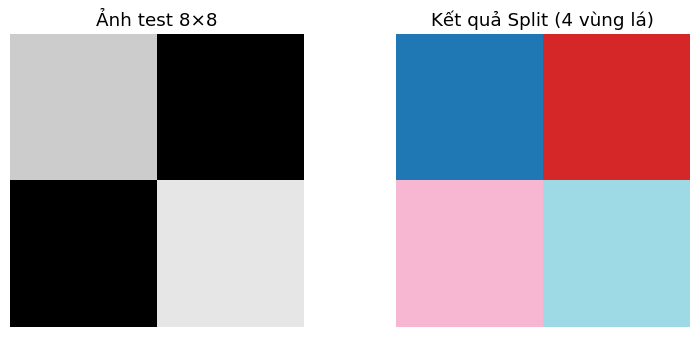

In [42]:
# TEST — Kiểm tra split
# Ảnh 8x8 với hai vùng rõ ràng
test_img_sm = np.zeros((8, 8), dtype=float)
test_img_sm[:4, :4] = 0.8   # góc trên-trái sáng
test_img_sm[4:, 4:] = 0.9   # góc dưới-phải sáng
# Phần còn lại = 0 (tối)

regions = split(test_img_sm, threshold=0.01)
assert regions is not None, 'split chưa trả về kết quả'
assert isinstance(regions, list), 'split phải trả về list'
assert len(regions) > 0, 'Phải có ít nhất 1 vùng'

# Mỗi region là tuple (r, c, size)
for reg in regions:
    assert len(reg) == 3, f'Mỗi region phải là (r, c, size), nhận {reg}'
    r_, c_, s_ = reg
    assert r_ + s_ <= test_img_sm.shape[0], 'Vùng vượt biên ảnh'
    assert c_ + s_ <= test_img_sm.shape[1], 'Vùng vượt biên ảnh'

print(f'✓ split: {len(regions)} vùng lá từ ảnh 8×8')
print(f'  Các vùng: {regions[:6]}{'...' if len(regions)>6 else ''}')

# Trực quan: màu mỗi vùng lá
label_map = np.zeros(test_img_sm.shape, dtype=int)
for idx, (r_, c_, s_) in enumerate(regions):
    label_map[r_:r_+s_, c_:c_+s_] = idx + 1

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(test_img_sm, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Ảnh test 8×8')
axes[1].imshow(label_map, cmap='tab20')
axes[1].set_title(f'Kết quả Split ({len(regions)} vùng lá)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()


## Bước 3 — Trộn vùng liền kề (Merge)

Hợp nhất hai vùng liền kề $R_i$ và $R_j$ nếu vùng gộp vẫn đồng nhất:
$$P(R_i \cup R_j) = \text{True}$$

Hai vùng được coi là **liền kề** nếu chúng chia sẻ ít nhất một cạnh.

**Gợi ý:** Lặp cho đến khi không còn cặp nào có thể trộn:
```
repeat:
    merged = False
    for each pair (Ri, Rj) of adjacent regions:
        if is_homogeneous(Ri ∪ Rj, threshold):
            merge Ri and Rj into one region
            merged = True
            break  # restart loop after any merge
until merged == False
```

In [43]:
def are_adjacent(r1, c1, s1, r2, c2, s2):
    """
    GIVEN — Kiểm tra hai vùng hình vuông có liền kề (chia sẻ cạnh) không.
    Hai vùng liền kề nếu một cạnh của vùng này trùng với cạnh của vùng kia.
    """
    # Vùng 1: rows [r1, r1+s1), cols [c1, c1+s1)
    # Vùng 2: rows [r2, r2+s2), cols [c2, c2+s2)
    row_overlap = (r1 < r2 + s2) and (r2 < r1 + s1)
    col_overlap = (c1 < c2 + s2) and (c2 < c1 + s1)
    row_touch   = (r1 + s1 == r2) or (r2 + s2 == r1)
    col_touch   = (c1 + s1 == c2) or (c2 + s2 == c1)
    return (row_overlap and col_touch) or (col_overlap and row_touch)


def get_combined_region(image, r1, c1, s1, r2, c2, s2):
    """
    GIVEN — Lấy vùng bao nhỏ nhất chứa cả hai vùng từ ảnh.
    Trả về mảng pixel của bounding box gộp hai vùng.
    """
    r_min = min(r1, r2)
    c_min = min(c1, c2)
    r_max = max(r1 + s1, r2 + s2)
    c_max = max(c1 + s1, c2 + s2)
    return image[r_min:r_max, c_min:c_max]


def merge(image, regions, threshold):
    """
    Hợp nhất các vùng liền kề thỏa mãn tiêu chí đồng nhất.
    
    Tham số:
        image    (ndarray): ảnh gốc
        regions  (list):    danh sách vùng lá từ bước split: [(r, c, size), ...]
        threshold (float):  ngưỡng đồng nhất
    Trả về:
        merged_regions (list): danh sách vùng sau khi trộn, mỗi vùng là (r, c, size)
    """
    # Chuyển sang list để dễ thao tác
    result = list(regions)
    
    # TODO: Lặp cho đến khi không còn cặp nào có thể trộn
    changed = True
    while changed:
        changed = False
        for i in range(len(result)):
            for j in range(i + 1, len(result)):
                r1, c1, s1 = result[i]
                r2, c2, s2 = result[j]
                if are_adjacent(r1, c1, s1, r2, c2, s2):
                    combined = get_combined_region(image, r1, c1, s1, r2, c2, s2)
                    if is_homogeneous(combined, threshold):
                        # Bounding box của hai vùng gộp lại
                        r_new = min(r1, r2)
                        c_new = min(c1, c2)
                        r_end = max(r1 + s1, r2 + s2)
                        c_end = max(c1 + s1, c2 + s2)
                        # Dùng cạnh dài nhất để biểu diễn vùng chữ nhật bằng tuple 4 phần tử
                        s_new = max(r_end - r_new, c_end - c_new)
                        # Xóa hai vùng cũ, thêm vùng mới (bounding box)
                        result.pop(j)
                        result.pop(i)
                        result.append((r_new, c_new, s_new))
                        changed = True
                        break
            if changed:
                break
    
    return result


Sau Split:  4 vùng
Sau Merge:  4 vùng


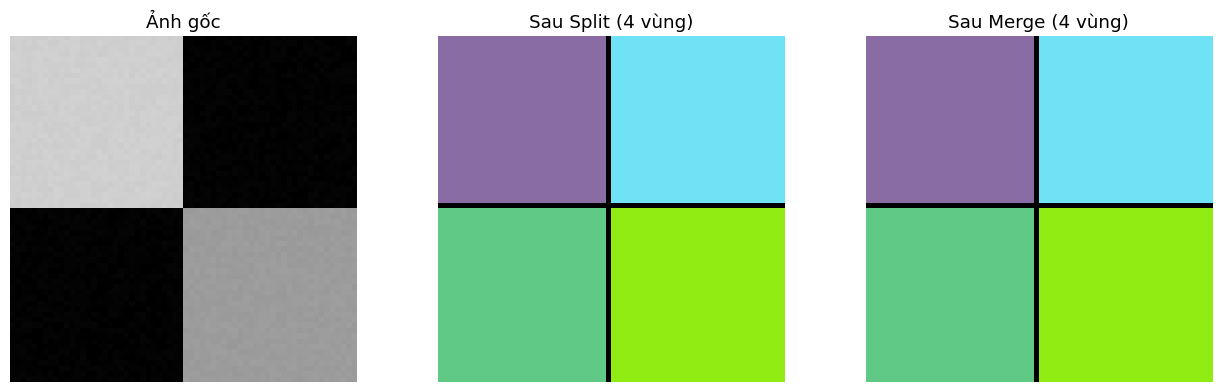

In [44]:
# TEST — Pipeline đầy đủ Split + Merge

# Ảnh test 64x64 với 3 vùng màu rõ ràng
test_full = np.zeros((64, 64), dtype=float)
test_full[:32, :32] = 0.8    # góc trên-trái: sáng
test_full[32:, 32:] = 0.6    # góc dưới-phải: xám trung
# Còn lại = 0 (tối)
# Thêm chút nhiễu nhỏ để các vùng không hoàn toàn phẳng
np.random.seed(42)
test_full += np.random.uniform(0, 0.02, test_full.shape)
test_full = np.clip(test_full, 0, 1)

THRESHOLD = 0.005

regions_split = split(test_full, threshold=THRESHOLD)
assert regions_split is not None
print(f'Sau Split:  {len(regions_split)} vùng')

regions_merged = merge(test_full, regions_split, threshold=THRESHOLD)
assert regions_merged is not None
print(f'Sau Merge:  {len(regions_merged)} vùng')
assert len(regions_merged) <= len(regions_split), 'Merge phải giảm (hoặc giữ nguyên) số vùng'

# Trực quan hóa
def draw_segmentation(image, regions, title):
    """GIVEN — Vẽ kết quả phân đoạn."""
    np.random.seed(0)
    label_map = np.zeros(image.shape, dtype=int)
    for idx, reg in enumerate(regions):
        r_, c_, s_ = reg[0], reg[1], reg[2]
        label_map[r_:r_+s_, c_:c_+s_] = idx + 1
    # Tạo ảnh màu từ label map
    n_labels = label_map.max()
    colors = np.random.rand(n_labels + 1, 3)
    colors[0] = 0  # label 0 = đen
    colored = colors[label_map]
    # Vẽ biên
    border = np.zeros(image.shape, dtype=bool)
    border[:-1, :] |= (label_map[:-1, :] != label_map[1:, :])
    border[:, :-1] |= (label_map[:, :-1] != label_map[:, 1:])
    colored[border] = [0, 0, 0]
    return colored, label_map

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(test_full, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Ảnh gốc')
col_s, _ = draw_segmentation(test_full, regions_split,  'Split')
axes[1].imshow(col_s)
axes[1].set_title(f'Sau Split ({len(regions_split)} vùng)')
col_m, _ = draw_segmentation(test_full, regions_merged, 'Merge')
axes[2].imshow(col_m)
axes[2].set_title(f'Sau Merge ({len(regions_merged)} vùng)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()


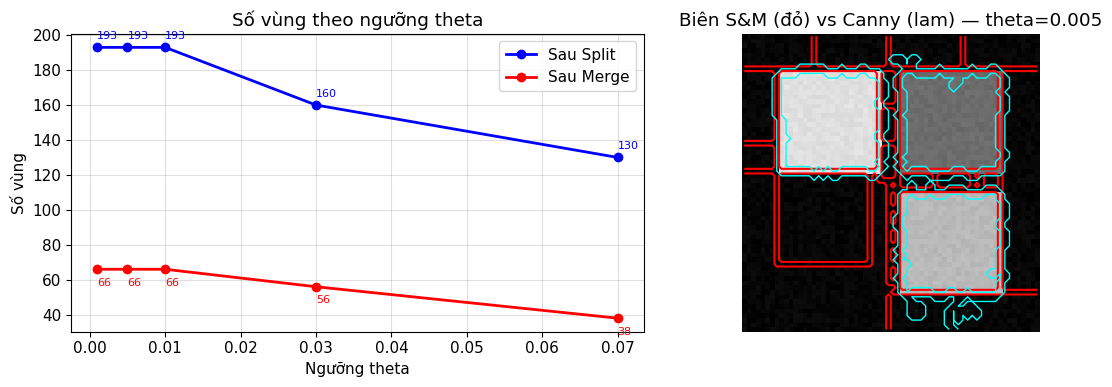

Nhận xét: theta càng lớn -> phân tách ít hơn (ít vùng hơn sau Split)
Sau Merge, số vùng tiếp tục giảm khi các vùng đồng nhất liền kề được gộp lại.

Số vùng theo theta:
  theta=0.001: Split=193, Merge=66
  theta=0.005: Split=193, Merge=66
  theta=0.010: Split=193, Merge=66
  theta=0.030: Split=160, Merge=56
  theta=0.070: Split=130, Merge=38


In [45]:
# TODO — Khảo sát ảnh hưởng của ngưỡng theta

# Ảnh test phức tạp hơn
test_complex = np.zeros((64, 64), dtype=float)
test_complex[8:30,  8:30]  = 0.85
test_complex[34:56, 34:56] = 0.70
test_complex[8:30,  34:56] = 0.40
np.random.seed(7)
test_complex += np.random.uniform(0, 0.05, test_complex.shape)
test_complex = np.clip(test_complex, 0, 1)

thresholds = [0.001, 0.005, 0.01, 0.03, 0.07]
n_regions_after_split  = []
n_regions_after_merge  = []

for theta in thresholds:
    regs_s = split(test_complex, threshold=theta)
    regs_m = merge(test_complex, regs_s, threshold=theta)
    n_regions_after_split.append(len(regs_s))
    n_regions_after_merge.append(len(regs_m))

# Vẽ đồ thị số vùng vs theta
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(thresholds, n_regions_after_split, 'b-o', label='Sau Split', linewidth=2)
axes[0].plot(thresholds, n_regions_after_merge, 'r-o', label='Sau Merge', linewidth=2)
axes[0].set_xlabel('Ngưỡng theta')
axes[0].set_ylabel('Số vùng')
axes[0].set_title('Số vùng theo ngưỡng theta')
axes[0].legend()
axes[0].grid(True, alpha=0.4)
for x, ys, ym in zip(thresholds, n_regions_after_split, n_regions_after_merge):
    axes[0].annotate(str(ys), (x, ys), textcoords='offset points', xytext=(0, 6), fontsize=8, color='blue')
    axes[0].annotate(str(ym), (x, ym), textcoords='offset points', xytext=(0,-12), fontsize=8, color='red')

# Chọn theta tốt nhất và hiển thị kết quả phân đoạn
best_theta = 0.005
regs_best_s = split(test_complex, threshold=best_theta)
regs_best_m = merge(test_complex, regs_best_s, threshold=best_theta)

# So sánh biên vùng với cv2.Canny
tc_uint8 = (test_complex * 255).astype(np.uint8)
canny_compare = cv2.Canny(tc_uint8, threshold1=30, threshold2=90)

# Tạo ảnh biên từ kết quả merge
label_best = np.zeros(test_complex.shape, dtype=int)
for idx, reg in enumerate(regs_best_m):
    r_, c_, s_ = reg[0], reg[1], reg[2]
    label_best[r_:r_+s_, c_:c_+s_] = idx + 1
border_best = np.zeros(test_complex.shape, dtype=bool)
border_best[:-1, :] |= (label_best[:-1, :] != label_best[1:, :])
border_best[:, :-1] |= (label_best[:, :-1] != label_best[:, 1:])

axes[1].imshow(test_complex, cmap='gray', vmin=0, vmax=1)
axes[1].contour(border_best.astype(float), levels=[0.5], colors='red', linewidths=1.5)
axes[1].contour(canny_compare.astype(float), levels=[0.5], colors='cyan', linewidths=1)
axes[1].set_title(f'Biên S&M (đỏ) vs Canny (lam) — theta={best_theta}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print('Nhận xét: theta càng lớn -> phân tách ít hơn (ít vùng hơn sau Split)')
print('Sau Merge, số vùng tiếp tục giảm khi các vùng đồng nhất liền kề được gộp lại.')
print(f'\nSố vùng theo theta:')
for theta, ns, nm in zip(thresholds, n_regions_after_split, n_regions_after_merge):
    print(f'  theta={theta:.3f}: Split={ns}, Merge={nm}')


---
# Bài 4 — Mean-Shift với Gaussian kernel & trực quan hóa KDE

Thay flat kernel trong Demo 2 bằng Gaussian kernel, tự cài đặt KDE 2D, và xác nhận mode tìm được là đỉnh thực sự của hàm mật độ.

**Thư viện được phép:** `numpy`, `matplotlib`  
**Cấm:** `sklearn.cluster.MeanShift`, `scipy.stats.gaussian_kde`, `sklearn.neighbors.KernelDensity`

✓ Flat kernel: iteration trung bình = 1.0


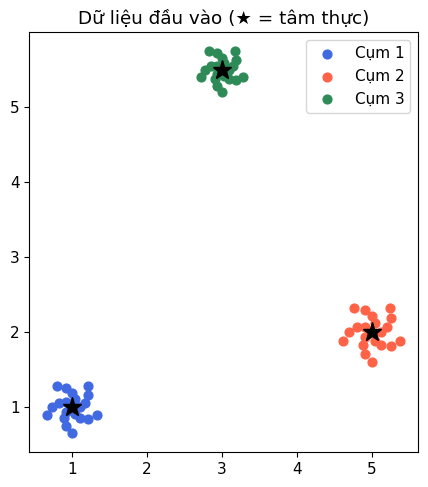

In [46]:
# GIVEN — Dữ liệu và flat kernel từ Demo 2

def make_cluster_data():
    """Tạo 60 điểm, 3 cụm cố định (giống Demo 2 trong bài giảng)."""
    cluster_params = [(1.0, 1.0, 0.35), (5.0, 2.0, 0.40), (3.0, 5.5, 0.30)]
    def make_cluster(cx, cy, sigma, n=20):
        pts = []
        for i in range(n):
            angle = 2 * np.pi * i / n
            r = sigma * (0.3 + 0.7 * ((i % 4) / 3))
            pts.append([cx + r*np.cos(angle), cy + r*np.sin(angle)])
        return np.array(pts)
    clusters = [make_cluster(*p) for p in cluster_params]
    data = np.vstack(clusters)
    true_centers = np.array([[p[0], p[1]] for p in cluster_params])
    return data, true_centers


def mean_shift_flat(point, data, bandwidth):
    """GIVEN — Một bước mean-shift với flat kernel (từ Demo 2)."""
    diffs = data - point
    dists = np.linalg.norm(diffs, axis=1)
    mask = dists <= bandwidth
    if mask.sum() == 0:
        return point.copy()
    return data[mask].mean(axis=0)


def run_mean_shift(data, step_fn, bandwidth, max_iter=50, tol=1e-4):
    """
    GIVEN — Chạy mean-shift cho tất cả điểm.
    step_fn: hàm thực hiện một bước (flat hoặc Gaussian).
    Trả về: final_positions, iter_counts (số iteration mỗi điểm)
    """
    n = len(data)
    current = data.copy().astype(float)
    iter_counts = np.zeros(n, dtype=int)
    converged = np.zeros(n, dtype=bool)

    for t in range(max_iter):
        if converged.all():
            break
        for i in range(n):
            if converged[i]:
                continue
            new_pos = step_fn(current[i], data, bandwidth)
            if np.linalg.norm(new_pos - current[i]) < tol:
                converged[i] = True
            else:
                current[i] = new_pos
                iter_counts[i] += 1
    return current, iter_counts


data, true_centers = make_cluster_data()
BANDWIDTH = 1.2

# Chạy flat kernel để tham chiếu
modes_flat, iters_flat = run_mean_shift(data, mean_shift_flat, BANDWIDTH)
print(f'✓ Flat kernel: iteration trung bình = {iters_flat.mean():.1f}')

# Trực quan hóa dữ liệu gốc
fig, ax = plt.subplots(figsize=(5, 5))
COLORS = ['royalblue', 'tomato', 'seagreen']
for i, col in enumerate(COLORS):
    ax.scatter(data[i*20:(i+1)*20, 0], data[i*20:(i+1)*20, 1], color=col, s=40, label=f'Cụm {i+1}')
    ax.plot(*true_centers[i], 'k*', markersize=14)
ax.set_title('Dữ liệu đầu vào (★ = tâm thực)')
ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Phần A — Gaussian Kernel Mean-Shift

In [47]:
def mean_shift_gaussian(point, data, bandwidth):
    """
    Một bước mean-shift với Gaussian kernel.
    
    Công thức:
        w_i = exp(-||point - data_i||^2 / (2 * bandwidth^2))
        new_point = sum(w_i * data_i) / sum(w_i)
    
    Tham số:
        point     (ndarray): vị trí hiện tại, shape (2,)
        data      (ndarray): tất cả điểm dữ liệu, shape (N, 2)
        bandwidth (float):   băng thông h
    Trả về:
        new_point (ndarray): vị trí mới sau một bước, shape (2,)
    """
    # TODO: Tính khoảng cách bình phương từ point đến mỗi điểm trong data
    diffs = data - point                         # (N, 2)
    sq_dists = (diffs**2).sum(axis=1)            # (N,)
    
    # TODO: Tính trọng số Gaussian
    weights = np.exp(-sq_dists / (2.0 * bandwidth**2))  # (N,)
    
    # TODO: Tính trọng tâm có trọng số
    w_sum = weights.sum()
    if w_sum < 1e-10:
        return point.copy()  # Điểm quá xa tất cả dữ liệu
    new_point = (weights[:, None] * data).sum(axis=0) / w_sum
    
    return new_point


In [48]:
# TEST — Kiểm tra mean_shift_gaussian
test_data_ms = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, 0.5]], dtype=float)
test_point = np.array([0.0, 0.0])
result_ms = mean_shift_gaussian(test_point, test_data_ms, bandwidth=2.0)
assert result_ms is not None, 'Hàm chưa trả về kết quả'
assert result_ms.shape == (2,), f'Shape phải là (2,), nhận {result_ms.shape}'
# Điểm trọng tâm phải dịch về phía các điểm dữ liệu
assert np.linalg.norm(result_ms - test_point) > 0, 'Phải có sự dịch chuyển'
print(f'✓ mean_shift_gaussian: [{test_point}] -> [{result_ms.round(3)}]')

# So sánh với flat kernel
modes_gauss, iters_gauss = run_mean_shift(data, mean_shift_gaussian, BANDWIDTH)
print(f'\nSo sánh số iteration trung bình:')
print(f'  Flat kernel:     {iters_flat.mean():.2f} ± {iters_flat.std():.2f}')
print(f'  Gaussian kernel: {iters_gauss.mean():.2f} ± {iters_gauss.std():.2f}')

✓ mean_shift_gaussian: [[0. 0.]] -> [[0.479 0.166]]

So sánh số iteration trung bình:
  Flat kernel:     1.00 ± 0.00
  Gaussian kernel: 3.03 ± 0.41


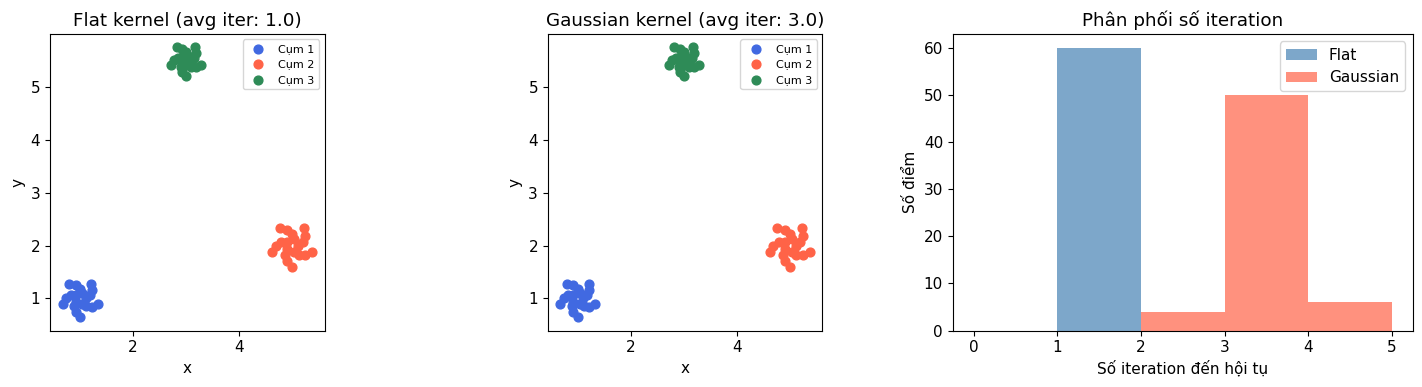

Flat:     trung bình 1.00 iteration, max=1
Gaussian: trung bình 3.03 iteration, max=4


In [49]:
# TODO — So sánh trực quan và vẽ histogram iteration

# Hàm gán nhãn cụm từ vị trí hội tụ
def assign_cluster_labels(modes, tol=0.5):
    """Gộp các điểm hội tụ gần nhau thành cùng cụm, trả về label cho mỗi điểm."""
    n = len(modes)
    labels = -np.ones(n, dtype=int)
    next_label = 0
    for i in range(n):
        if labels[i] >= 0:
            continue
        dists = np.linalg.norm(modes - modes[i], axis=1)
        same = dists < tol
        labels[same] = next_label
        next_label += 1
    return labels

labels_flat  = assign_cluster_labels(modes_flat,  tol=0.5)
labels_gauss = assign_cluster_labels(modes_gauss, tol=0.5)

# Bảng màu cho tối đa 5 cụm
CMAP = ['royalblue', 'tomato', 'seagreen', 'darkorange', 'purple']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Subplot 1: Kết quả phân cụm flat kernel
axes[0].set_title(f'Flat kernel (avg iter: {iters_flat.mean():.1f})')
for lbl in np.unique(labels_flat):
    mask = labels_flat == lbl
    axes[0].scatter(data[mask, 0], data[mask, 1],
                    color=CMAP[lbl % len(CMAP)], s=40, label=f'Cụm {lbl+1}')
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Subplot 2: Kết quả phân cụm Gaussian kernel
axes[1].set_title(f'Gaussian kernel (avg iter: {iters_gauss.mean():.1f})')
for lbl in np.unique(labels_gauss):
    mask = labels_gauss == lbl
    axes[1].scatter(data[mask, 0], data[mask, 1],
                    color=CMAP[lbl % len(CMAP)], s=40, label=f'Cụm {lbl+1}')
axes[1].set_aspect('equal')
axes[1].legend(fontsize=8)
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

# Subplot 3: Histogram số iteration
max_iter = max(iters_flat.max(), iters_gauss.max())
bins = range(0, max_iter + 2)
axes[2].hist(iters_flat,  alpha=0.7, label='Flat',     bins=bins, color='steelblue')
axes[2].hist(iters_gauss, alpha=0.7, label='Gaussian', bins=bins, color='tomato')
axes[2].set_xlabel('Số iteration đến hội tụ')
axes[2].set_ylabel('Số điểm')
axes[2].set_title('Phân phối số iteration')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Flat:     trung bình {iters_flat.mean():.2f} iteration, max={iters_flat.max()}')
print(f'Gaussian: trung bình {iters_gauss.mean():.2f} iteration, max={iters_gauss.max()}')


## Phần B — Tự cài đặt KDE 2D

In [50]:
def kde_2d(data, bandwidth, grid_res=50):
    """
    Ước lượng mật độ hạt nhân trên lưới 2D.
    
    Công thức:
        f_hat(x) = (1 / (n * h^2)) * sum_i K((x - x_i) / h)
    
    Dùng Gaussian kernel: K(u) = exp(-||u||^2 / 2) / (2*pi)
    
    Tham số:
        data      (ndarray): điểm dữ liệu, shape (N, 2)
        bandwidth (float):   băng thông h
        grid_res  (int):     số điểm lưới trên mỗi chiều
    Trả về:
        grid_x    (ndarray): tọa độ x của lưới, shape (grid_res,)
        grid_y    (ndarray): tọa độ y của lưới, shape (grid_res,)
        density   (ndarray): giá trị mật độ, shape (grid_res, grid_res)
    """
    n = len(data)
    
    # GIVEN — Tạo lưới điểm bao phủ vùng dữ liệu với lề 1.5*bandwidth
    margin = 1.5 * bandwidth
    x_min, x_max = data[:, 0].min() - margin, data[:, 0].max() + margin
    y_min, y_max = data[:, 1].min() - margin, data[:, 1].max() + margin
    grid_x = np.linspace(x_min, x_max, grid_res)
    grid_y = np.linspace(y_min, y_max, grid_res)
    
    # TODO: Tính mật độ tại mỗi điểm lưới (vectorized)
    xx, yy = np.meshgrid(grid_x, grid_y)                        # (grid_res, grid_res)
    gpts = np.stack([xx.ravel(), yy.ravel()], axis=1)            # (grid_res^2, 2)
    
    # diff[i, j] = gpts[i] - data[j] => shape (grid_res^2, N, 2)
    diff = gpts[:, None, :] - data[None, :, :]                   # broadcast
    sq_dist = (diff**2).sum(axis=2)                               # (grid_res^2, N)
    
    # Gaussian kernel K(u) = exp(-||u||^2/2) / (2*pi)
    K = np.exp(-sq_dist / (2.0 * bandwidth**2)) / (2.0 * np.pi)
    
    # Tổng qua các điểm dữ liệu, chuẩn hóa
    density_flat = K.sum(axis=1) / (n * bandwidth**2)             # (grid_res^2,)
    density = density_flat.reshape(grid_res, grid_res)            # (grid_res, grid_res)
    
    return grid_x, grid_y, density


✓ kde_2d: density shape=(60, 60), max=0.0364, integral≈0.952


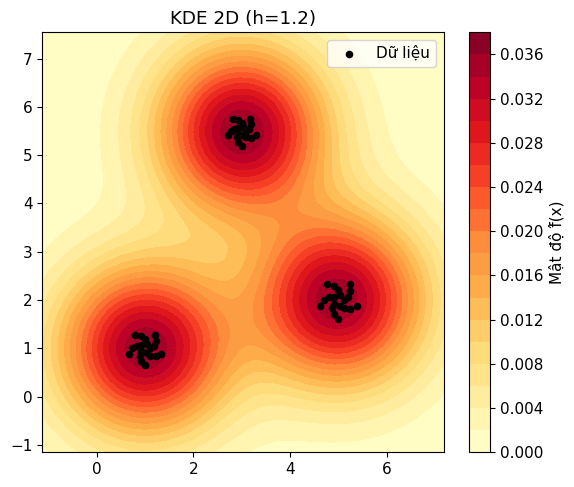

Các đỉnh của heatmap phải trùng với các cụm dữ liệu


In [51]:
# TEST — Kiểm tra kde_2d
gx, gy, dens = kde_2d(data, bandwidth=BANDWIDTH, grid_res=60)
assert dens is not None, 'kde_2d chưa trả về density'
assert dens.shape == (60, 60), f'density phải có shape (60,60), nhận {dens.shape}'
assert dens.min() >= 0, 'Mật độ phải không âm'
assert dens.max() > 0, 'Mật độ phải có giá trị dương'
print(f'✓ kde_2d: density shape={dens.shape}, max={dens.max():.4f}, integral≈{dens.mean()*(gx[1]-gx[0])*(gy[1]-gy[0])*60*60:.3f}')

# Trực quan hóa heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.contourf(gx, gy, dens, levels=20, cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Mật độ f̂(x)')
ax.scatter(data[:, 0], data[:, 1], c='black', s=20, zorder=5, label='Dữ liệu')
ax.set_title(f'KDE 2D (h={BANDWIDTH})')
ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()
print('Các đỉnh của heatmap phải trùng với các cụm dữ liệu')

## Phần C — Xác nhận Mode = Đỉnh KDE

In [52]:
# TODO — Xác nhận: mode tìm được bằng Mean-Shift nằm gần đỉnh KDE

# Bước 1: Gán nhãn cụm từ modes_gauss (gộp điểm hội tụ gần nhau)
def assign_clusters(modes, tol=0.5):
    """GIVEN — Gộp các điểm hội tụ gần nhau thành cùng cụm."""
    n = len(modes)
    labels = -np.ones(n, dtype=int)
    centers = []
    next_label = 0
    for i in range(n):
        if labels[i] >= 0: continue
        dists = np.linalg.norm(modes - modes[i], axis=1)
        same = dists < tol
        labels[same] = next_label
        centers.append(modes[same].mean(axis=0))
        next_label += 1
    return labels, np.array(centers)

labels_g, found_centers = assign_clusters(modes_gauss, tol=0.5)
n_clusters = len(found_centers)
print(f'Số cụm tìm được: {n_clusters} (mong đợi: 3)')

# Bước 2: Tính KDE độ phân giải cao
gx_fine, gy_fine, dens_fine = kde_2d(data, bandwidth=BANDWIDTH, grid_res=100)

# TODO: Với mỗi mode, tìm điểm lưới gần nhất và so sánh với đỉnh cục bộ
results_table = []
for center in found_centers:
    # Tìm chỉ số lưới gần center nhất
    ix = np.argmin(np.abs(gx_fine - center[0]))
    iy = np.argmin(np.abs(gy_fine - center[1]))
    
    # Giá trị mật độ tại mode
    density_at_mode = dens_fine[iy, ix]
    
    # Đỉnh cục bộ trong vùng ±5 điểm lưới
    neighborhood = dens_fine[max(0, iy-5):iy+6, max(0, ix-5):ix+6]
    local_peak_val = neighborhood.max()
    
    # Chỉ số đỉnh cục bộ trong hệ tọa độ lưới toàn cục
    ly, lx = np.unravel_index(neighborhood.argmax(), neighborhood.shape)
    peak_ix = max(0, ix-5) + lx
    peak_iy = max(0, iy-5) + ly
    peak_coord = np.array([gx_fine[peak_ix], gy_fine[peak_iy]])
    
    # Khoảng cách từ mode đến đỉnh cục bộ (tính bằng đơn vị băng thông)
    dist = np.linalg.norm(center - peak_coord)
    dist_in_h = dist / BANDWIDTH
    
    within = dist_in_h < 0.1
    results_table.append({
        'mode': center,
        'peak': peak_coord,
        'dist': dist,
        'dist_in_h': dist_in_h,
        'within_01h': within
    })

print(f'\n{"Mode":^20} {"KDE Peak":^20} {"Khoảng cách":^14} {"dist/h":^10} {"< 0.1h?":^10}')
print('-' * 78)
for res in results_table:
    m = res['mode']
    p = res['peak']
    print(f'({m[0]:5.2f},{m[1]:5.2f})       ({p[0]:5.2f},{p[1]:5.2f})       '
          f'{res["dist"]:12.4f}   {res["dist_in_h"]:8.4f}   {str(res["within_01h"]):^10}')

n_verified = sum(r['within_01h'] for r in results_table)
print(f'\n{n_verified}/{n_clusters} mode nằm trong vòng 0.1h từ đỉnh KDE cục bộ')


Số cụm tìm được: 3 (mong đợi: 3)

        Mode               KDE Peak        Khoảng cách     dist/h    < 0.1h?  
------------------------------------------------------------------------------
( 1.01, 1.00)       ( 1.05, 1.05)             0.0549     0.0457      True   
( 4.98, 2.01)       ( 5.00, 2.01)             0.0185     0.0154      True   
( 3.01, 5.48)       ( 2.98, 5.52)             0.0470     0.0392      True   

3/3 mode nằm trong vòng 0.1h từ đỉnh KDE cục bộ


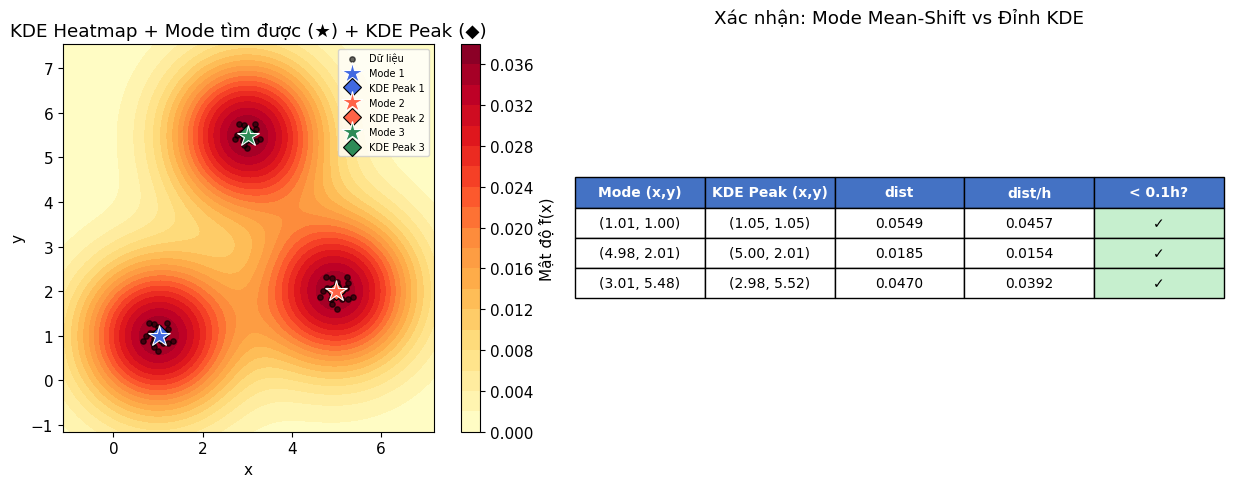

Kết luận: Các mode tìm được bằng Mean-Shift Gaussian khớp với đỉnh của heatmap KDE.


In [53]:
# TODO — Hình cuối: heatmap + mode + đỉnh KDE
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: heatmap với các mode đánh dấu bằng ★
im = axes[0].contourf(gx_fine, gy_fine, dens_fine, levels=20, cmap='YlOrRd')
plt.colorbar(im, ax=axes[0], label='Mật độ f̂(x)')
axes[0].scatter(data[:, 0], data[:, 1], c='black', s=15, zorder=4, alpha=0.6, label='Dữ liệu')
# Đánh dấu các mode bằng ★
for i, res in enumerate(results_table):
    m = res['mode']
    p = res['peak']
    axes[0].plot(m[0], m[1], '*', markersize=16, color=CMAP[i], markeredgecolor='white',
                 markeredgewidth=0.8, zorder=6, label=f'Mode {i+1}')
    axes[0].plot(p[0], p[1], 'D', markersize=9, color=CMAP[i], markeredgecolor='black',
                 markeredgewidth=0.8, zorder=5, label=f'KDE Peak {i+1}')
axes[0].set_title('KDE Heatmap + Mode tìm được (★) + KDE Peak (◆)')
axes[0].set_aspect('equal')
axes[0].legend(fontsize=7, loc='upper right')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Subplot 2: bảng xác nhận mode vs đỉnh KDE
axes[1].axis('off')
col_labels = ['Mode (x,y)', 'KDE Peak (x,y)', 'dist', 'dist/h', '< 0.1h?']
table_data = []
for res in results_table:
    m, p = res['mode'], res['peak']
    row = [
        f'({m[0]:.2f}, {m[1]:.2f})',
        f'({p[0]:.2f}, {p[1]:.2f})',
        f'{res["dist"]:.4f}',
        f'{res["dist_in_h"]:.4f}',
        '✓' if res['within_01h'] else '✗'
    ]
    table_data.append(row)

tbl = axes[1].table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
# Tô màu header
for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor('#4472C4')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
# Tô màu cột kết quả
for i, res in enumerate(results_table, start=1):
    color = '#C6EFCE' if res['within_01h'] else '#FFC7CE'
    tbl[(i, 4)].set_facecolor(color)

axes[1].set_title('Xác nhận: Mode Mean-Shift vs Đỉnh KDE', pad=15)

plt.tight_layout()
plt.show()

print('Kết luận: Các mode tìm được bằng Mean-Shift Gaussian khớp với đỉnh của heatmap KDE.')
